# Flesch-Kincaid Readability Analysis

This notebook performs readability tests on the Trump speech corpus using the `textstat` library. We calculate three key metrics:
1. **Flesch-Kincaid Grade Level**: Indicates the U.S. school grade level needed to understand the text.
2. **Gunning Fog Index**: Estimates the years of formal education needed to understand the text on the first reading.
3. **Flesch Reading Ease**: Scores text on a scale of 0-100, where higher scores indicate easier reading.

We analyze these metrics over time and by various categories.

In [14]:
import sys
import os
from pathlib import Path

# Add src to path
project_root = Path("..").resolve()
sys.path.append(str(project_root / "src"))

# Ensure textstat is installed in the current kernel
!pip install textstat

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textstat
import nltk
import ssl
from analysis.speech_corpus import SpeechCorpus

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Fix for NLTK download SSL error
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download necessary NLTK data
nltk.download('cmudict')
nltk.download('punkt')

[nltk_data] Downloading package cmudict to /Users/rgeron/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!
[nltk_data] Downloading package punkt to /Users/rgeron/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## 1. Load Data

In [15]:
corpus = SpeechCorpus(data_dir="../data")
print(corpus)

<SpeechCorpus: 894 speeches, 121034 transcriptions>


## 2. Define Calculation Logic

We define a function to calculate the metrics safely, handling potential errors.

In [16]:
def calculate_readability_metrics(text):
    """
    Calculate readability metrics for a given text using textstat.
    Returns a dictionary with the scores.
    """
    if not isinstance(text, str) or not text.strip():
        return {
            "flesch_kincaid_grade": None,
            "gunning_fog": None,
            "flesch_reading_ease": None
        }
        
    try:
        return {
            "flesch_kincaid_grade": textstat.flesch_kincaid_grade(text),
            "gunning_fog": textstat.gunning_fog(text),
            "flesch_reading_ease": textstat.flesch_reading_ease(text)
        }
    except Exception as e:
        # print(f"Error processing text: {e}") # Optional: uncomment to see errors
        return {
            "flesch_kincaid_grade": None,
            "gunning_fog": None,
            "flesch_reading_ease": None
        }

## 3. Test on Small Subset

We test the function on a small subset of speeches to ensure it works correctly.

In [17]:
# Merge speeches with transcriptions to get the text
# We use the 'text' column from transcriptions, which contains the raw text with punctuation
df = corpus.speeches.merge(corpus.transcriptions, left_on="id", right_on="speech_id", how="inner")

# Test on first 5 speeches
subset = df.head(5).copy()
print("Testing on subset of 5 speeches...")
subset_results = subset['text'].apply(calculate_readability_metrics)
subset_df = pd.json_normalize(subset_results)
print(subset_df)
print("Test complete.")

Testing on subset of 5 speeches...
   flesch_kincaid_grade  gunning_fog  flesch_reading_ease
0              4.794706     6.886275            80.872843
1              7.860517     8.829885            47.315374
2              5.057333     7.579683            81.246000
3              6.936818     9.472727            55.125227
4              8.047949     9.864304            65.504329
Test complete.


## 4. Apply to Full Corpus

Now we apply the calculation to the entire dataset.

In [18]:
print(f"Processing {len(df)} speeches...")

results = df['text'].apply(calculate_readability_metrics)

# Expand results into columns
df_results = pd.json_normalize(results)
df = pd.concat([df.reset_index(drop=True), df_results], axis=1)

# Filter out failed calculations
df = df.dropna(subset=['flesch_kincaid_grade'])

print(f"Successfully processed {len(df)} speeches.")

Processing 121034 speeches...
Successfully processed 121034 speeches.


## 5. Visualization: Evolution Over Time

We visualize the Flesch-Kincaid Grade Level over time with a trendline.

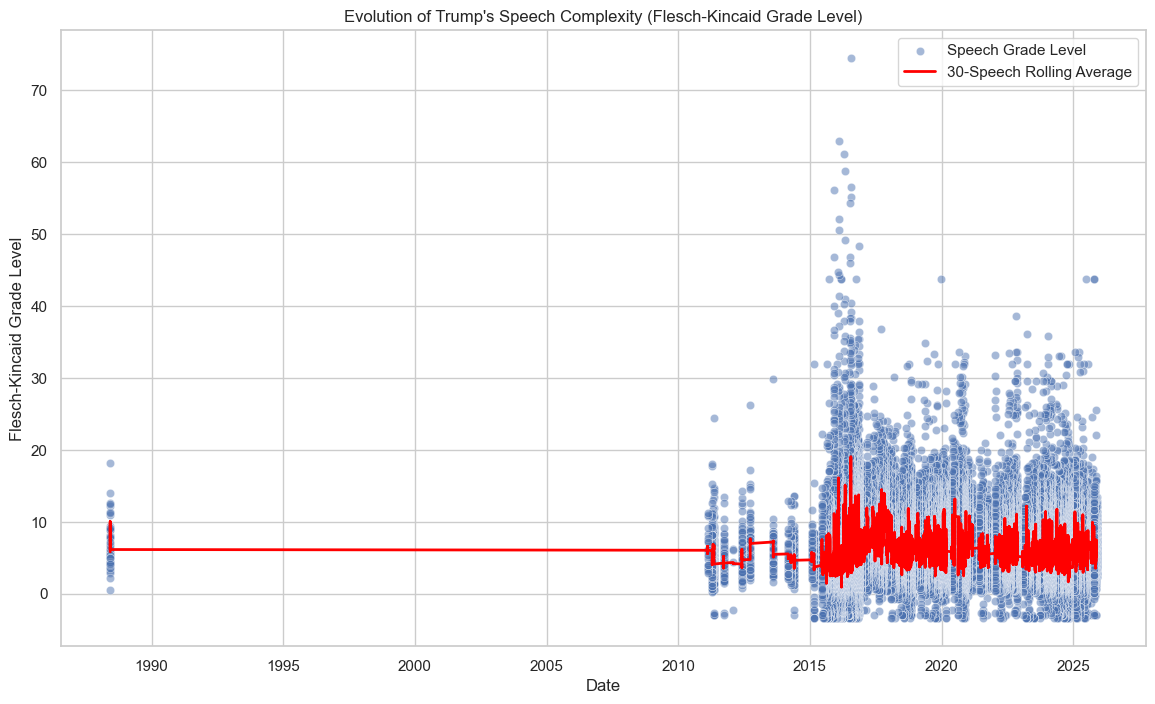

In [19]:
# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(14, 8))
sns.scatterplot(data=df, x='date', y='flesch_kincaid_grade', alpha=0.5, label='Speech Grade Level')

# Add trendline (Rolling Average)
df_sorted = df.sort_values('date')
df_sorted['rolling_avg'] = df_sorted['flesch_kincaid_grade'].rolling(window=30, min_periods=1).mean()
plt.plot(df_sorted['date'], df_sorted['rolling_avg'], color='red', linewidth=2, label='30-Speech Rolling Average')

plt.title("Evolution of Trump's Speech Complexity (Flesch-Kincaid Grade Level)")
plt.xlabel("Date")
plt.ylabel("Flesch-Kincaid Grade Level")
plt.legend()
plt.show()

## 6. Global Analysis

In [20]:
metrics = ['flesch_kincaid_grade', 'gunning_fog', 'flesch_reading_ease']
print(df[metrics].describe())

       flesch_kincaid_grade    gunning_fog  flesch_reading_ease
count         121034.000000  121034.000000        121034.000000
mean               5.780025       7.744676            76.033488
std                3.546078       3.691128            16.838386
min               -3.400000       0.400000          -217.180000
25%                3.509778       5.378142            67.530000
50%                5.144104       7.045931            78.585784
75%                7.346316       9.312727            87.175586
max               74.471053      77.894737           121.220000


## 7. Analysis by Campaign Year

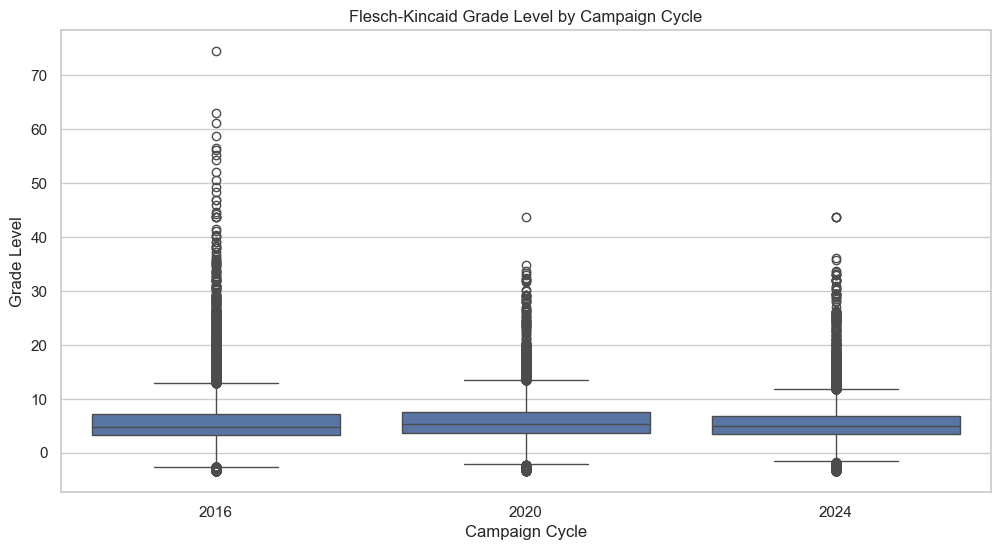

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='campaign', y='flesch_kincaid_grade', order=['2016', '2020', '2024'])
plt.title("Flesch-Kincaid Grade Level by Campaign Cycle")
plt.xlabel("Campaign Cycle")
plt.ylabel("Grade Level")
plt.show()

## 8. Analysis by Rally vs. Non-Rally

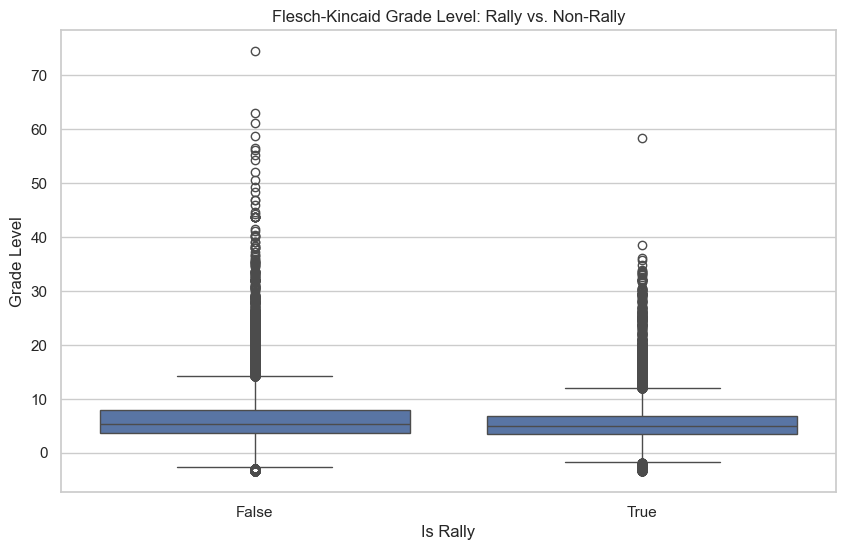

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_rally', y='flesch_kincaid_grade')
plt.title("Flesch-Kincaid Grade Level: Rally vs. Non-Rally")
plt.xlabel("Is Rally")
plt.ylabel("Grade Level")
plt.show()

## 9. Analysis by Location (Top 10)

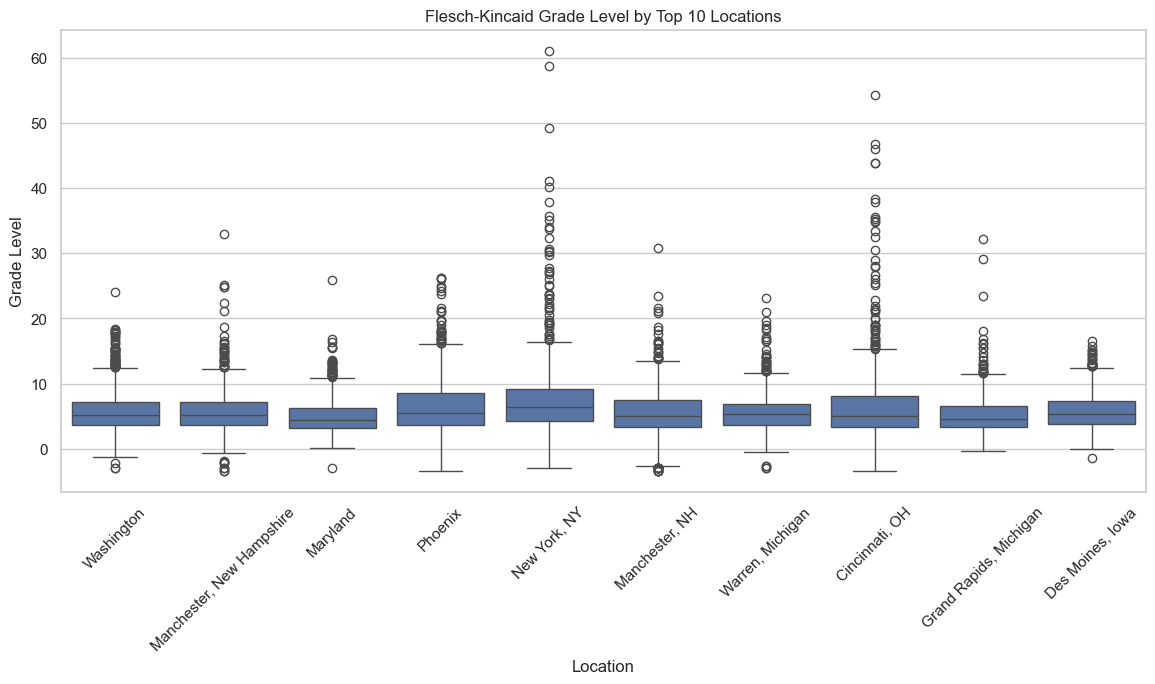

In [23]:
top_locations = df['location'].value_counts().head(10).index
df_top_loc = df[df['location'].isin(top_locations)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_top_loc, x='location', y='flesch_kincaid_grade', order=top_locations)
plt.title("Flesch-Kincaid Grade Level by Top 10 Locations")
plt.xlabel("Location")
plt.ylabel("Grade Level")
plt.xticks(rotation=45)
plt.show()